# Music collection overview

Figures are **saved to** `analysis/report/` **and shown inline** below each cell (standard notebook practice).

- **Danceability** uses softmax **index 0** (same as `collection_playlists` / `analyze_collection`; index 1 is the complement).
- **Tempo / danceability / loudness**: **three separate figures** so each histogram is readable in the overview mosaic (not one squeezed triptych).
- **Key profiles (Essentia)**: each profile outputs **key + scale** (tonal center, not a chord progression). Grouped bars show **top key+scale labels** across Temperley, Krumhansl, and Edma; then a **three-bar** summary of mean pairwise agreement with the other two, plus a **table** of the three pairwise agreement percentages.
- **No** overlaid min–max KDE of all metrics (removed as redundant).
- Final cell: **mosaic** PNG on disk and the same composite shown here.


In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Paths ---
cwd = Path.cwd().resolve()
if (cwd / "analysis" / "descriptors.jsonl").exists():
    ROOT = cwd
elif (cwd.parent / "analysis" / "descriptors.jsonl").exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate analysis/descriptors.jsonl from cwd")

ANALYSIS_PATH = ROOT / "analysis" / "descriptors.jsonl"
REPORT_DIR = ROOT / "analysis" / "report"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Collect saved figure paths for the final mosaic
FIGURE_PATHS: list[Path] = []


def save_current_figure(name: str) -> Path:
    """Write PNG to ``analysis/report`` and display the figure in the notebook."""
    p = REPORT_DIR / name
    fig = plt.gcf()
    fig.savefig(p, dpi=160, bbox_inches="tight", facecolor="white", edgecolor="none")
    FIGURE_PATHS.append(p)
    plt.show()
    plt.close(fig)
    return p


# --- Visual defaults (clean, high-contrast) ---
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "figure.facecolor": "white",
        "axes.facecolor": "#f6f7f9",
        "axes.edgecolor": "#d8dde6",
        "axes.labelcolor": "#1a1d24",
        "axes.titleweight": "600",
        "axes.titlesize": 12,
        "text.color": "#1a1d24",
        "xtick.color": "#3a3f4a",
        "ytick.color": "#3a3f4a",
        "font.size": 10,
        "grid.color": "#e2e5ec",
        "grid.linestyle": "-",
        "grid.alpha": 0.85,
    }
)
sns.set_theme(style="whitegrid", palette="deep")

ANALYSIS_PATH


PosixPath('/home/trekar/Descargas/musav-recommender/analysis/descriptors.jsonl')

In [ ]:
rows = [json.loads(line) for line in ANALYSIS_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]
len(rows)


2100

In [ ]:
df = pd.DataFrame(
    {
        "relative_path": [r["relative_path"] for r in rows],
        "tempo_bpm": [r.get("tempo_bpm") for r in rows],
        "loudness_lufs": [r.get("loudness_lufs") for r in rows],
        # danceability_mean is a 2-way softmax; index 0 is the score used in collection_playlists filters.
        "danceability": [
            (r.get("classifiers", {}).get("danceability_mean", [np.nan, np.nan]) or [np.nan, np.nan])[0]
            for r in rows
        ],
        # voice_instrumental_mean: [instrumental, vocal] (Essentia convention).
        "instrumental_prob": [
            (r.get("classifiers", {}).get("voice_instrumental_mean", [np.nan, np.nan]) or [np.nan, np.nan])[0]
            for r in rows
        ],
        "vocal_prob": [
            (r.get("classifiers", {}).get("voice_instrumental_mean", [np.nan, np.nan]) or [np.nan, np.nan])[1]
            for r in rows
        ],
        "style_activations": [
            r.get("classifiers", {}).get("discogs400_style_activations_mean", [])
            for r in rows
        ],
        "key_temperley": [r.get("key", {}).get("temperley", {}).get("key") for r in rows],
        "scale_temperley": [r.get("key", {}).get("temperley", {}).get("scale") for r in rows],
        "key_krumhansl": [r.get("key", {}).get("krumhansl", {}).get("key") for r in rows],
        "scale_krumhansl": [r.get("key", {}).get("krumhansl", {}).get("scale") for r in rows],
        "key_edma": [r.get("key", {}).get("edma", {}).get("key") for r in rows],
        "scale_edma": [r.get("key", {}).get("edma", {}).get("scale") for r in rows],
    }
)

num_tracks = len(df)
num_tracks


2100

In [ ]:
def load_style_labels(root: Path, expected_len: int) -> list[str]:
    """Load Discogs400 style labels from the official Essentia model metadata JSON."""
    meta_path = root / "models" / "genre_discogs400-discogs-effnet-1.json"
    if not meta_path.exists():
        return [f"style_{i:03d}" for i in range(expected_len)]

    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    classes = meta.get("classes")
    if not isinstance(classes, list) or len(classes) != expected_len:
        got_len = len(classes) if isinstance(classes, list) else "n/a"
        raise ValueError(
            f"Unexpected classes field in {meta_path}: "
            f"expected list of length {expected_len}, got {type(classes)} len={got_len}"
        )
    return [str(x) for x in classes]


def parent_genre(label: str) -> str:
    for sep in ("---", "--", "—"):
        if sep in label:
            return label.split(sep, 1)[0].strip()
    if "-" in label and not label.startswith("style_"):
        return label.split("-", 1)[0].strip()
    return "unknown"


style_dim = len(df["style_activations"].iloc[0])
style_labels = load_style_labels(ROOT, style_dim)

style_matrix = np.vstack(df["style_activations"].to_numpy())
style_top1_idx = style_matrix.argmax(axis=1)
style_top1_label = [style_labels[i] for i in style_top1_idx]

df["style_top1"] = style_top1_label
df["broad_genre_top1"] = [parent_genre(s) for s in style_top1_label]

STYLE_THRESHOLD = 0.10
style_binary = (style_matrix >= STYLE_THRESHOLD).astype(int)

style_stats = pd.DataFrame(
    {
        "style_id": np.arange(style_dim),
        "style_label": style_labels,
        "broad_genre": [parent_genre(s) for s in style_labels],
        "mean_activation": style_matrix.mean(axis=0),
        "top1_count": np.bincount(style_top1_idx, minlength=style_dim),
        "tracks_above_threshold": style_binary.sum(axis=0),
    }
).sort_values("tracks_above_threshold", ascending=False)

style_tsv_path = REPORT_DIR / "styles_distribution.tsv"
style_stats.to_csv(style_tsv_path, sep="\t", index=False)
style_tsv_path


PosixPath('/home/trekar/Descargas/musav-recommender/analysis/report/styles_distribution.tsv')

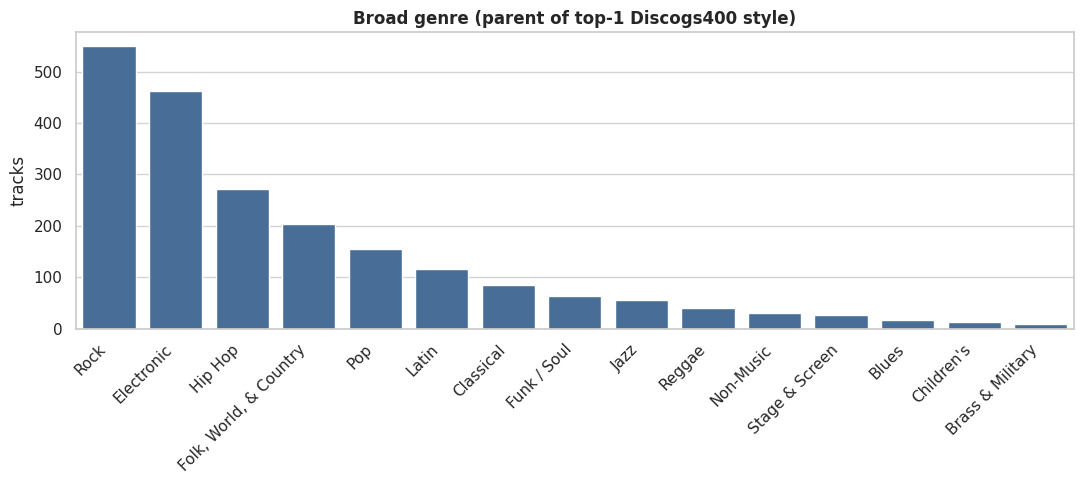

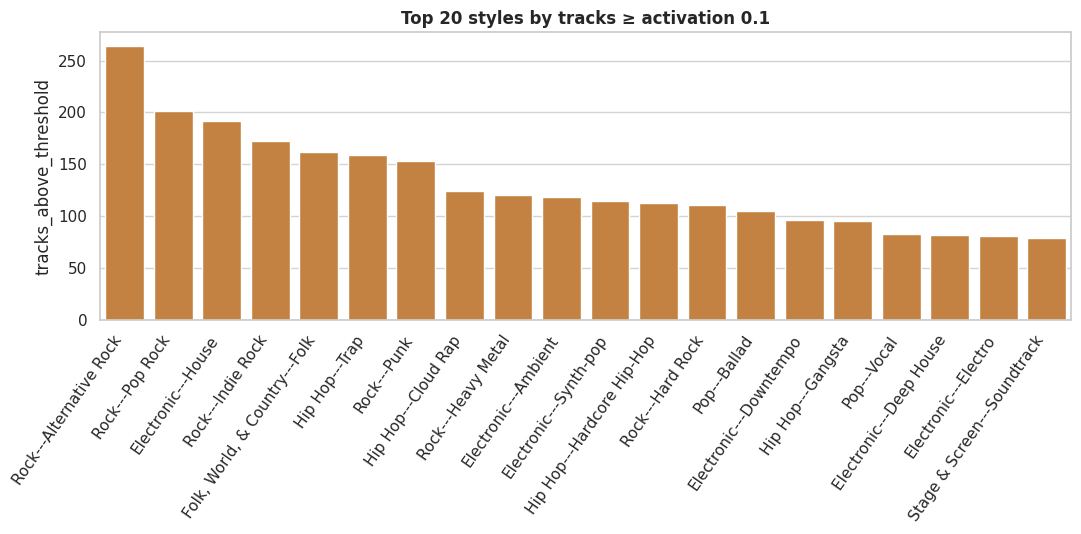

PosixPath('/home/trekar/Descargas/musav-recommender/analysis/report/02_styles_top20.png')

In [ ]:
broad_counts = (
    df["broad_genre_top1"].value_counts().rename_axis("broad_genre").reset_index(name="tracks")
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=broad_counts, x="broad_genre", y="tracks", color="#3b6ea5", ax=ax)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("Broad genre (parent of top-1 Discogs400 style)")
ax.set_xlabel("")
fig.tight_layout()
save_current_figure("01_broad_genre.png")

style_top20 = style_stats.head(20)
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=style_top20, x="style_label", y="tracks_above_threshold", color="#d9822b", ax=ax)
plt.setp(ax.get_xticklabels(), rotation=55, ha="right")
ax.set_title(f"Top 20 styles by tracks ≥ activation {STYLE_THRESHOLD}")
ax.set_xlabel("")
fig.tight_layout()
save_current_figure("02_styles_top20.png")


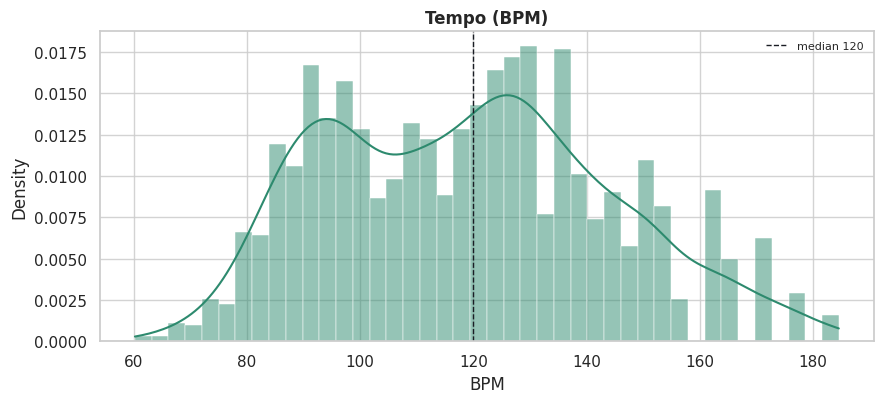

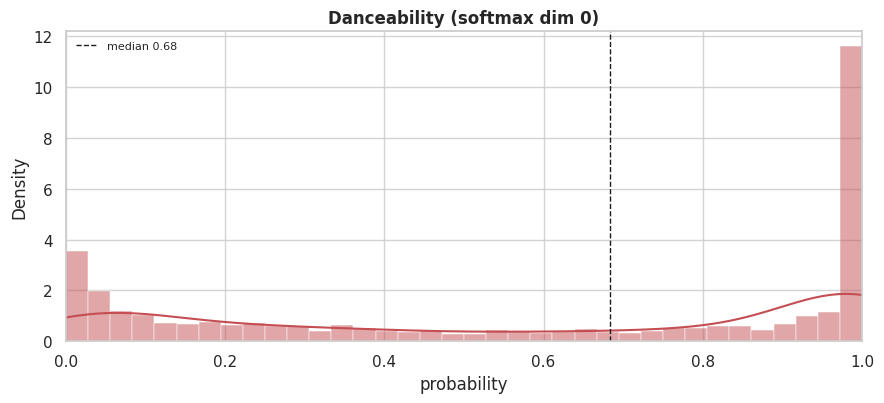

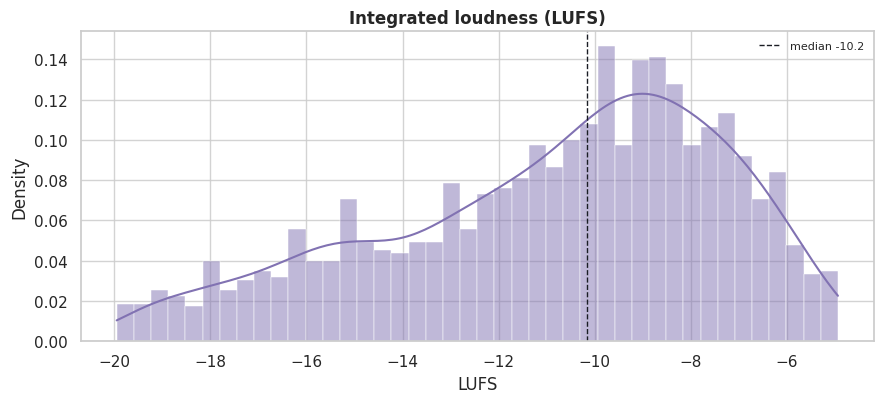

PosixPath('/home/trekar/Descargas/musav-recommender/analysis/report/05_loudness_lufs.png')

In [ ]:
# One figure per metric so each panel stays legible in the mosaic overview.
fig, ax = plt.subplots(figsize=(9, 4.2))
sns.histplot(df["tempo_bpm"].dropna(), bins=42, kde=True, ax=ax, color="#2d8a6e", stat="density", edgecolor="white", linewidth=0.35)
ax.set_title("Tempo (BPM)")
ax.set_xlabel("BPM")
ax.axvline(df["tempo_bpm"].median(), color="#1a1d24", ls="--", lw=1, label=f"median {df['tempo_bpm'].median():.0f}")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
save_current_figure("03_tempo_bpm.png")

fig, ax = plt.subplots(figsize=(9, 4.2))
sns.histplot(df["danceability"].dropna(), bins=36, kde=True, ax=ax, color="#c44e52", stat="density", edgecolor="white", linewidth=0.35)
ax.set_title("Danceability (softmax dim 0)")
ax.set_xlabel("probability")
ax.set_xlim(0, 1)
ax.axvline(df["danceability"].median(), color="#1a1d24", ls="--", lw=1, label=f"median {df['danceability'].median():.2f}")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
save_current_figure("04_danceability_dim0.png")

fig, ax = plt.subplots(figsize=(9, 4.2))
sns.histplot(df["loudness_lufs"].dropna(), bins=42, kde=True, ax=ax, color="#8172b2", stat="density", edgecolor="white", linewidth=0.35)
ax.set_title("Integrated loudness (LUFS)")
ax.set_xlabel("LUFS")
ax.axvline(df["loudness_lufs"].median(), color="#1a1d24", ls="--", lw=1, label=f"median {df['loudness_lufs'].median():.1f}")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
save_current_figure("05_loudness_lufs.png")


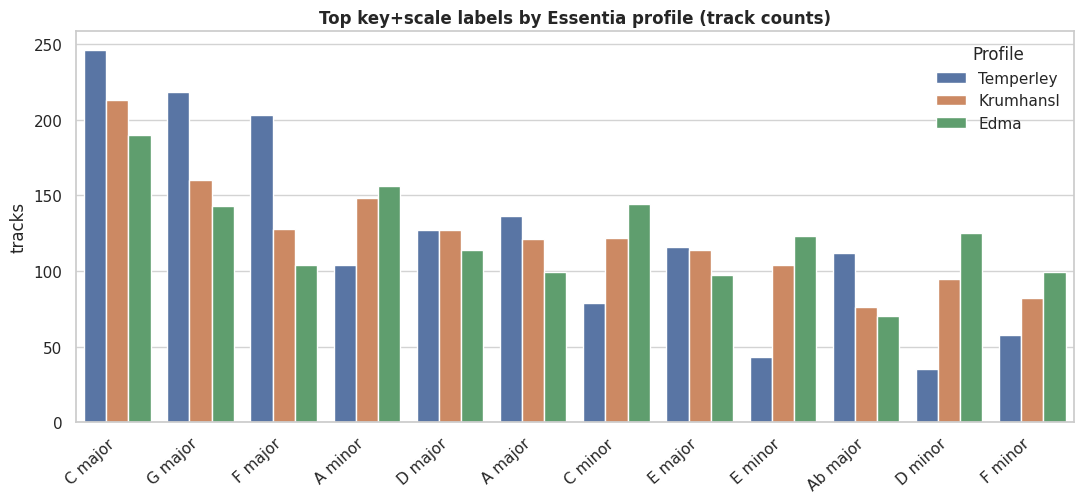

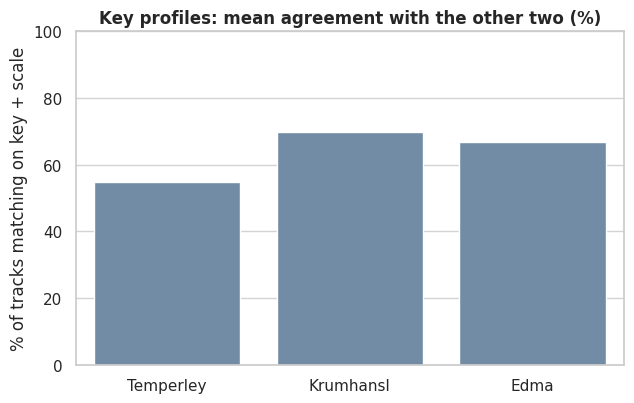

49.095238095238095

In [ ]:
profiles = ["temperley", "krumhansl", "edma"]
profile_labels = ["Temperley", "Krumhansl", "Edma"]


def pair_agreement(a: str, b: str) -> float:
    """Percent of tracks where profile *a* and *b* agree on key and scale."""
    return 100 * (
        (df[f"key_{a}"] == df[f"key_{b}"]) & (df[f"scale_{a}"] == df[f"scale_{b}"])
    ).mean()


pairwise = pd.DataFrame(
    {
        "pair": ["temperley vs krumhansl", "temperley vs edma", "krumhansl vs edma"],
        "agreement_pct": [
            pair_agreement("temperley", "krumhansl"),
            pair_agreement("temperley", "edma"),
            pair_agreement("krumhansl", "edma"),
        ],
    }
)


def key_scale_series(profile: str) -> pd.Series:
    return (
        df[f"key_{profile}"].astype(str).str.strip()
        + " "
        + df[f"scale_{profile}"].astype(str).str.strip()
    )


counts = {p: key_scale_series(p).value_counts() for p in profiles}
pool = set()
for p in profiles:
    pool.update(counts[p].head(14).index)


def _label_weight(lab: str) -> int:
    return sum(int(counts[p].get(lab, 0)) for p in profiles)


top_labels = sorted(pool, key=_label_weight, reverse=True)[:12]
long_rows: list[dict] = []
nice = dict(zip(profiles, profile_labels))
for lab in top_labels:
    for p in profiles:
        long_rows.append({"key_scale": lab, "profile": nice[p], "tracks": int(counts[p].get(lab, 0))})
top_long = pd.DataFrame(long_rows)

fig, ax = plt.subplots(figsize=(11, 5.2))
sns.barplot(
    data=top_long,
    x="key_scale",
    y="tracks",
    hue="profile",
    hue_order=profile_labels,
    order=top_labels,
    ax=ax,
)
ax.set_title("Top key+scale labels by Essentia profile (track counts)")
ax.set_xlabel("")
ax.set_ylabel("tracks")
ax.legend(title="Profile", frameon=False, loc="upper right")
plt.setp(ax.get_xticklabels(), rotation=42, ha="right")
fig.tight_layout()
save_current_figure("06_key_scale_top_by_profile.png")

# One bar per profile: average agreement with the other two (higher = more central / less idiosyncratic).
profile_scores = pd.DataFrame(
    {
        "profile": profile_labels,
        "mean_pairwise_agreement_pct": [
            (pair_agreement("temperley", "krumhansl") + pair_agreement("temperley", "edma")) / 2,
            (pair_agreement("temperley", "krumhansl") + pair_agreement("krumhansl", "edma")) / 2,
            (pair_agreement("temperley", "edma") + pair_agreement("krumhansl", "edma")) / 2,
        ],
    }
)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
sns.barplot(data=profile_scores, x="profile", y="mean_pairwise_agreement_pct", color="#6a8caf", ax=ax)
ax.set_title("Key profiles: mean agreement with the other two (%)")
ax.set_ylabel("% of tracks matching on key + scale")
ax.set_xlabel("")
ax.set_ylim(0, 100)
fig.tight_layout()
save_current_figure("07_key_profiles_mean_pairwise_agreement.png")

# Tracks where all three profiles agree on key and scale
all_agree = (
    (df["key_temperley"] == df["key_krumhansl"])
    & (df["key_temperley"] == df["key_edma"])
    & (df["scale_temperley"] == df["scale_krumhansl"])
    & (df["scale_temperley"] == df["scale_edma"])
)
agreement_pct = 100 * all_agree.mean()
agreement_pct


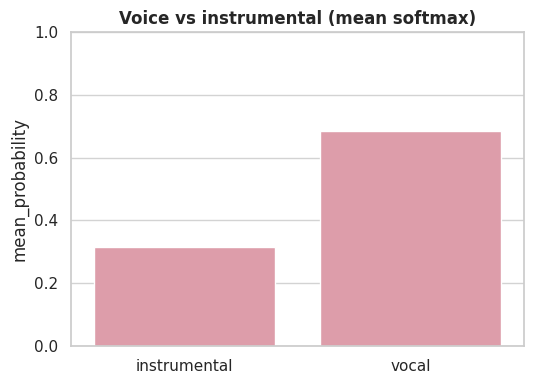

,class,mean_probability
0,instrumental,0.315623
1,vocal,0.684377


In [ ]:
voice_summary = pd.DataFrame(
    {
        "class": ["instrumental", "vocal"],
        "mean_probability": [df["instrumental_prob"].mean(), df["vocal_prob"].mean()],
    }
)

fig, ax = plt.subplots(figsize=(5.5, 4))
sns.barplot(data=voice_summary, x="class", y="mean_probability", color="#e892a4", ax=ax)
ax.set_title("Voice vs instrumental (mean softmax)")
ax.set_ylim(0, 1)
ax.set_xlabel("")
fig.tight_layout()
save_current_figure("08_voice_instrumental.png")

voice_summary


In [ ]:
# Pairwise key+scale agreement (% of tracks). Same underlying counts as the mean-profile bars above.
pairwise


,pair,agreement_pct
0,temperley vs krumhansl,57.857143
1,temperley vs edma,51.857143
2,krumhansl vs edma,81.952381


## Observations

- **Styles / genres**: use `analysis/report/styles_distribution.tsv` for full style-level counts and activations.
- **Tempo / danceability / loudness**: three saved histograms (BPM, softmax dim 0, LUFS); dashed lines are medians. Danceability is softmax **index 0** (playlist filters use the same).
- **Key profiles**: the **grouped** chart shows how often each top key+scale string is assigned under each detector; the **three-bar** chart averages the two pairwise agreements per profile; the **table** is raw pairwise agreement. **All three agree** is `agreement_pct` in the key cell.
- **Voice**: bar heights are mean softmax probabilities (instrumental vs vocal channels).


In [ ]:
profile_votes = {
    "temperley": (pair_agreement("temperley", "krumhansl") + pair_agreement("temperley", "edma")) / 2,
    "krumhansl": (pair_agreement("temperley", "krumhansl") + pair_agreement("krumhansl", "edma")) / 2,
    "edma": (pair_agreement("temperley", "edma") + pair_agreement("krumhansl", "edma")) / 2,
}
selected_profile = max(profile_votes, key=profile_votes.get)

summary = {
    "num_tracks": int(num_tracks),
    "num_styles": int(style_dim),
    "top10_broad_genres": broad_counts.head(10).to_dict(orient="records"),
    "all_three_key_agreement_pct": round(float(agreement_pct), 2),
    "pairwise_key_agreement_pct": {k: round(float(v), 2) for k, v in zip(pairwise["pair"], pairwise["agreement_pct"])},
    "recommended_single_profile": selected_profile,
    "tempo_mean_bpm": round(float(df["tempo_bpm"].mean()), 2),
    "tempo_std_bpm": round(float(df["tempo_bpm"].std()), 2),
    "danceability_mean_dim0": round(float(df["danceability"].mean()), 3),
    "loudness_mean_lufs": round(float(df["loudness_lufs"].mean()), 2),
    "vocal_probability_mean": round(float(df["vocal_prob"].mean()), 3),
}

summary


{'num_tracks': 2100,
 'num_styles': 400,
 'top10_broad_genres': [{'broad_genre': 'Rock', 'tracks': 549},
  {'broad_genre': 'Electronic', 'tracks': 463},
  {'broad_genre': 'Hip Hop', 'tracks': 271},
  {'broad_genre': 'Folk, World, & Country', 'tracks': 204},
  {'broad_genre': 'Pop', 'tracks': 155},
  {'broad_genre': 'Latin', 'tracks': 117},
  {'broad_genre': 'Classical', 'tracks': 86},
  {'broad_genre': 'Funk / Soul', 'tracks': 64},
  {'broad_genre': 'Jazz', 'tracks': 56},
  {'broad_genre': 'Reggae', 'tracks': 40}],
 'all_three_key_agreement_pct': 49.1,
 'pairwise_key_agreement_pct': {'temperley vs krumhansl': 57.86,
  'temperley vs edma': 51.86,
  'krumhansl vs edma': 81.95},
 'recommended_single_profile': 'krumhansl',
 'tempo_mean_bpm': 119.14,
 'tempo_std_bpm': 25.16,
 'danceability_mean_dim0': 0.582,
 'loudness_mean_lufs': -10.91,
 'vocal_probability_mean': 0.684}

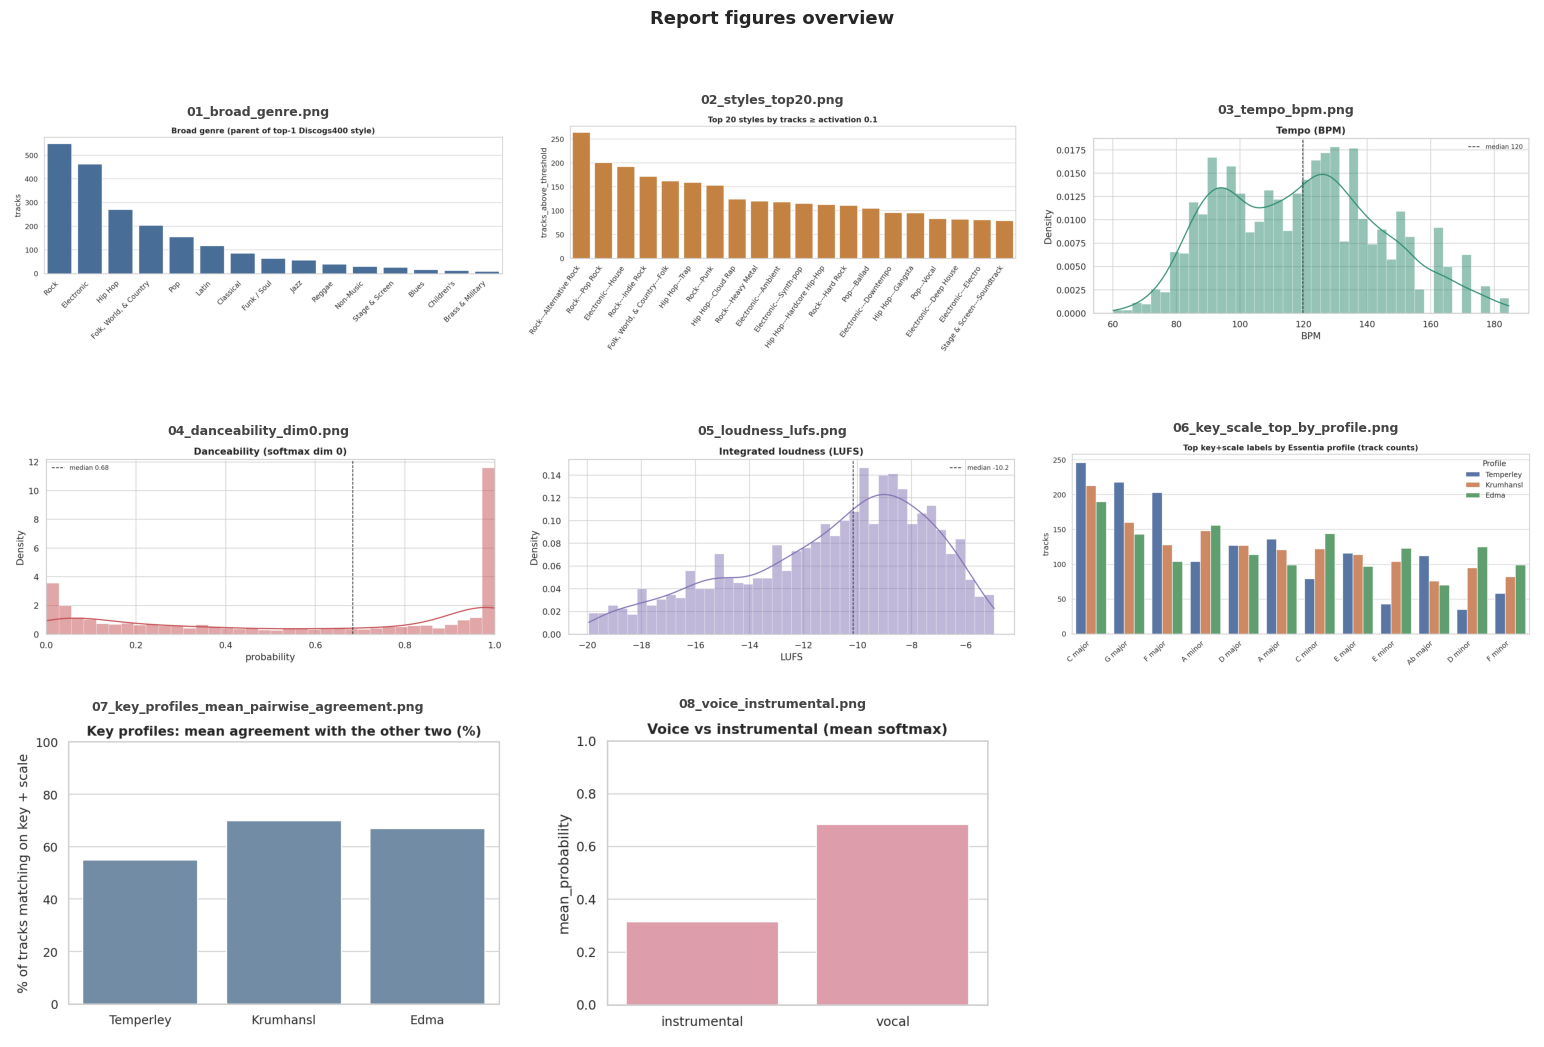

In [ ]:
# Mosaic: composite of all saved figures (saved + shown)
import matplotlib.image as mpimg

paths = [
    p
    for p in FIGURE_PATHS
    if p.exists() and p.name != "00_figure_overview_mosaic.png"
]
if len(paths) >= 2:
    n = len(paths)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.45 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, p in zip(axes, paths):
        ax.imshow(mpimg.imread(p))
        ax.set_title(p.name, fontsize=9, color="#444")
        ax.axis("off")
    for ax in axes[len(paths) :]:
        ax.axis("off")
    fig.suptitle("Report figures overview", fontsize=13, fontweight="600", y=1.01)
    fig.tight_layout()
    mosaic_path = REPORT_DIR / "00_figure_overview_mosaic.png"
    fig.savefig(mosaic_path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    mosaic_path
else:
    "Not enough figures saved for mosaic"
